In [2]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



## Why Data Transformation Is Required

### What is Data Transformation?

* It is the process of converting raw data into a more suitable format or scale to improve performance and accuracy in analysis or modeling.

### Why It's Important

* **Reduces Skewness**: Many real-world numerical features (like income or charges) are right-skewed.
* **Improves Model Performance**: Linear models assume normality and homoscedasticity; transformation helps.
* **Brings All Features to Comparable Scale**: This avoids bias toward high-magnitude features.
* **Handles Outliers Gently**: Some transformations compress the effect of large values.


## Common Types of Transformations

| Method | When to Use | Example Code |
| --- | --- | --- |
| **Log** | Right-skewed data (e.g., income, charges) | `df['log_exp'] = np.log1p(df['expenses'])` |
| **Box-Cox** | Positive values only; used when log transformation is not enough | `df['bmi_boxcox'], _ = boxcox(df['bmi']+1)` |
| **Z-score** | When standardizing features or detecting outliers using standard deviation | `(df - df.mean()) / df.std()` |
| **Min-Max** | When scaling features to a fixed range between 0 and 1 | `MinMaxScaler()` |
| **Power Transform** | Automatically selects the best transformation method between log and square root | `PowerTransformer()` from sklearn |

<Axes: xlabel='charges', ylabel='Count'>

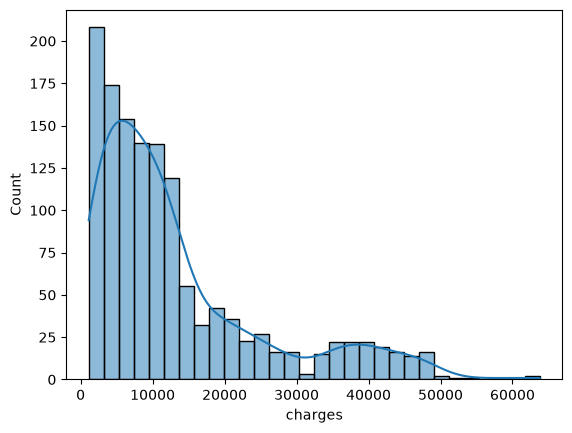

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)

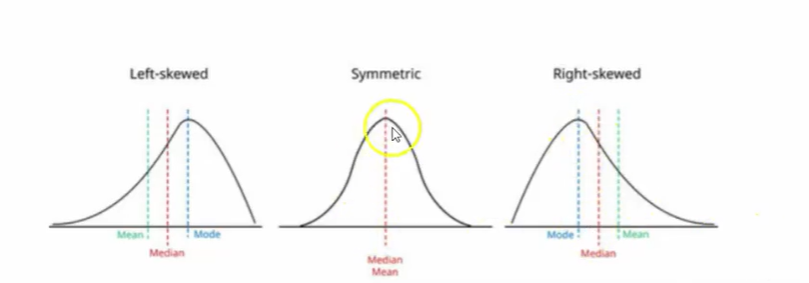

In [6]:
# Box-Cox on positive BMI
from scipy.stats import boxcox
df['bmi_boxcox'], _ = boxcox(df['bmi'] + 1)

<Axes: xlabel='log_charges', ylabel='Count'>

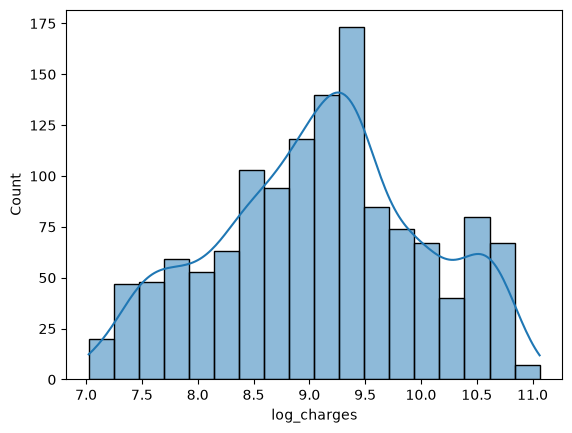

In [7]:
df['log_charges'] = np.log1p(df['charges'])
sns.histplot(df['log_charges'], kde=True)  # After transform

In [8]:
df.shape

(1338, 9)

In [9]:
### Inference: The transformed distribution is more symmetric, which is better for regression and visualization.

### in statistics whenever histogram is showing data distribution in form of bell shape curve ,

### it is normal distribution , otherwise skewed distribution

### Feature Engineering

- Create meaningful features:

In [10]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455


In [11]:
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=['under','normal','over','obese'])

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over


In [13]:
df['age_group'] = pd.cut(df['age'], bins=[17,30,45,60,100], labels=['young','adult','mature','senior'])

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult


In [15]:
df['age_smoker'] = df['age'] * (df['smoker']=='yes')

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0



## Data Distribution Analysis

* Transformed distributions help us better understand data patterns and reduce skewness.
* Boxplots are ideal for comparing how different groups affect a continuous variable.

<Axes: xlabel='log_charges', ylabel='Count'>

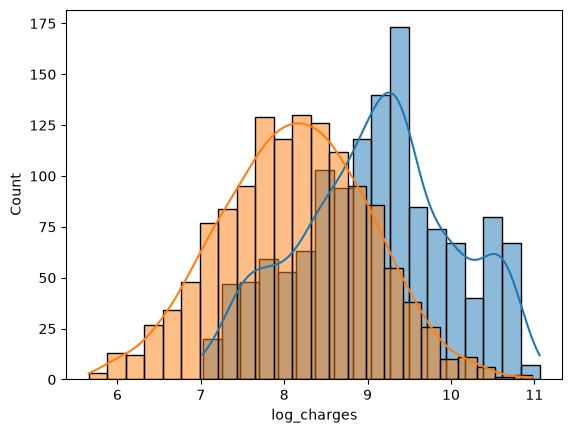

In [17]:
sns.histplot(df['log_charges'], kde = True)
sns.histplot(df['bmi_boxcox'], kde = True)



#inference

This plot shows the distribution of expenses after applying a log transformation.

Originally, the data was right-skewed, meaning most people had low expenses but a few had very high ones.

Log transformation makes the distribution more normal and symmetric — ideal for many statistical and machine learning models.

<Axes: xlabel='bmi_cat', ylabel='charges'>

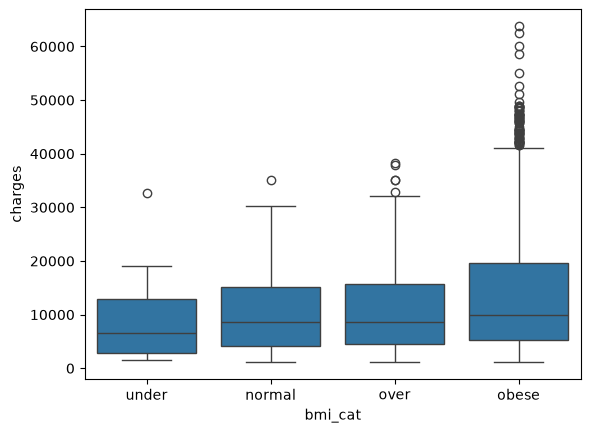

In [21]:
# Boxplot for categorical distributions
sns.boxplot(x='bmi_cat', y='charges', data=df)

there is no bmi_cat coloum but we created this using feature engeneering


* #inference
* This boxplot compares insurance expenses across BMI categories.
* You can observe that as BMI category increases — especially in 'Obese' — the average and variation in expenses tend to increase.
* This implies that higher BMI is associated with higher medical costs.

<Axes: xlabel='smoker', ylabel='charges'>

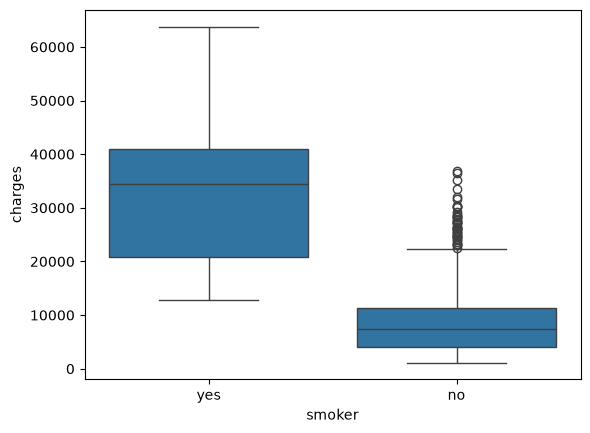

In [22]:
sns.boxplot(x='smoker', y='charges', data=df)


#inference
we clearly see that smokers have significantly higher expenses than non-smokers.

Not only is the median higher, but the spread is also wide - indicating that smoking is a major cost driver in medical insurance.

This kind of visualization is critical for risk segmentation in the insurance industry.

In [23]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0


<Axes: >

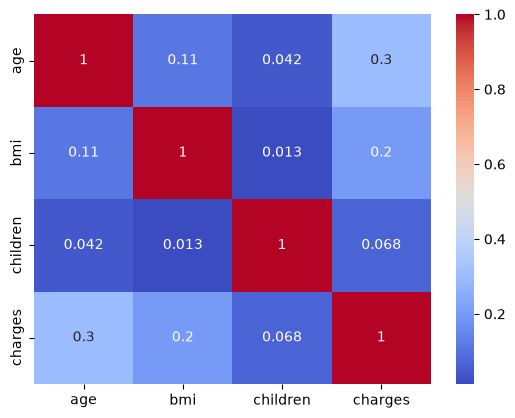

In [26]:
num_cols = ['age', 'bmi', 'children', 'charges']
corr = df[num_cols].corr()
sns.heatmap(corr,annot=True, cmap = 'coolwarm')

## Check the unique values for the categorical fields:

In [27]:
for col in['sex', 'smoker', 'region', 'bmi_cat','age_group']:
    print(col, df[col].value_counts())
    print()

sex sex
male      676
female    662
Name: count, dtype: int64

smoker smoker
no     1064
yes     274
Name: count, dtype: int64

region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

bmi_cat bmi_cat
obese     705
over      386
normal    226
under      21
Name: count, dtype: int64

age_group age_group
young     444
mature    409
adult     394
senior     91
Name: count, dtype: int64



### Target Variable Distribution

<Axes: xlabel='charges', ylabel='Count'>

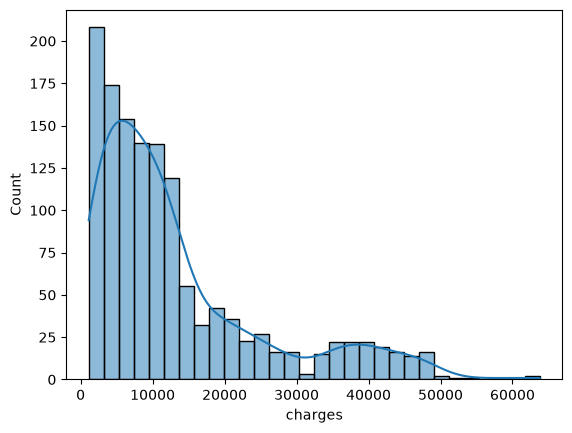

In [28]:
sns.histplot(df['charges'],kde=True)

<Axes: xlabel='log_charges', ylabel='Count'>

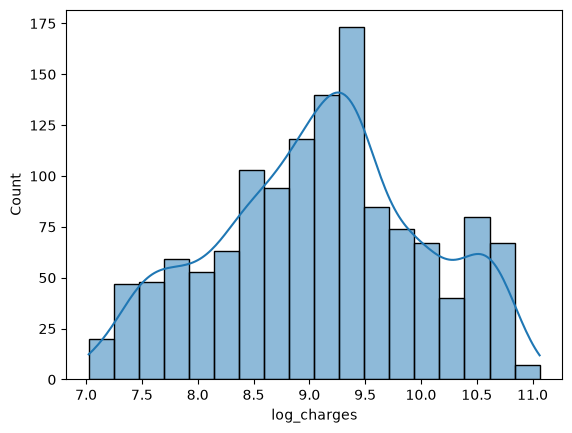

In [ ]:
sns.histplot(df['log_charges'],kde=True)
